# Task 11 — Ensemble Methods: Bagging, Boosting and Stacking

## Objective

The objective of this task is to understand and implement ensemble learning methods including Bagging, Boosting, Voting, and Stacking. Different machine learning models will be trained and compared on the Spaceship Titanic dataset to determine whether combining diverse models can improve predictive performance.

## Business Problem

Single machine learning models may reach a performance plateau. The goal is to combine multiple diverse models using ensemble techniques and identify whether an ensemble model, particularly stacking, can achieve better performance than individual models.

## Dataset

The Spaceship Titanic dataset from Kaggle is used for this task.

The target variable is `Transported`, which indicates whether a passenger was transported to another dimension.

## Key Techniques

- Bagging
- Random Forest
- Boosting
- XGBoost
- LightGBM
- CatBoost
- Voting Ensemble
- Stacking Ensemble
- Model Diversity Analysis

## 1. Import Libraries

The required Python libraries are imported for data handling, visualization, preprocessing, model training, ensemble learning, and evaluation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

The Spaceship Titanic dataset is loaded and its basic structure is inspected before preprocessing.

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Spaceship-Titanic.csv to Spaceship-Titanic (1).csv


In [5]:
import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 3. Initial Data Exploration

The dataset is inspected to understand its dimensions, data types, missing values, and target distribution. This helps identify the preprocessing steps required before model training.

In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (8693, 14)

Column Names:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']

Data Types:
PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

Missing Values:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

print("\nTarget Distribution:")
print(df["Transported"].value_counts())

print("\nTarget Distribution (%):")
print(df["Transported"].value_counts(normalize=True) * 100)

Duplicate Rows: 0

Target Distribution:
Transported
True     4378
False    4315
Name: count, dtype: int64

Target Distribution (%):
Transported
True     50.362361
False    49.637639
Name: proportion, dtype: float64


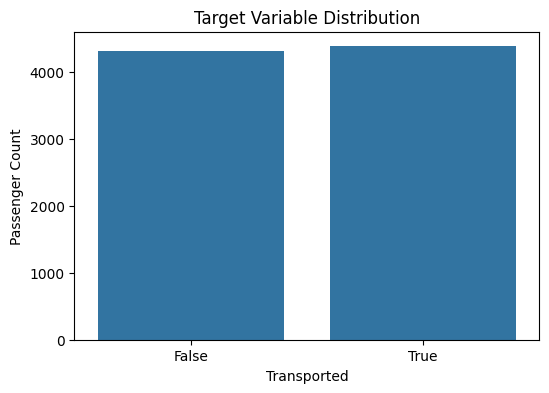

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Transported")

plt.title("Target Variable Distribution")
plt.xlabel("Transported")
plt.ylabel("Passenger Count")
plt.show()

## 4. Data Quality Analysis

The dataset contains passenger information, travel details, spending-related features, and the target variable. Missing values are examined to determine suitable preprocessing strategies for numerical and categorical features.

In [9]:
# Missing values summary

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percent
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
CryoSleep,217,2.496261
ShoppingMall,208,2.392730
VIP,203,2.335212
HomePlanet,201,2.312205
Name,200,2.300702
Cabin,199,2.289198
VRDeck,188,2.162660
FoodCourt,183,2.105142
Spa,183,2.105142
Destination,182,2.093639


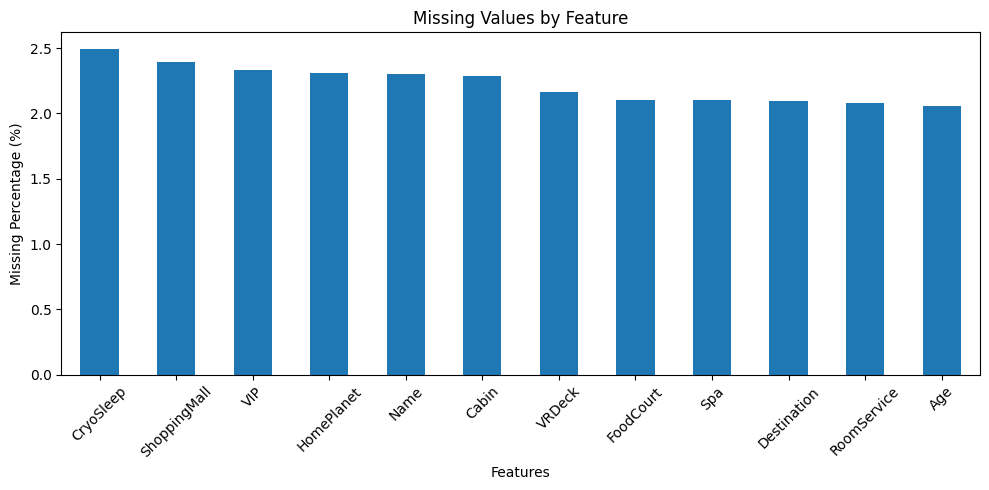

In [10]:
# Visualize missing values

plt.figure(figsize=(10, 5))

missing_summary["Missing Percentage"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Feature Understanding

The dataset contains demographic, travel, cabin, and spending-related variables. Features such as PassengerId and Name are mainly identifiers, while Cabin contains structured information that can be transformed into more useful components.

In [11]:
print("Unique values in categorical features:\n")

categorical_check = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "VIP"
]

for col in categorical_check:
    print(f"{col}:")
    print(df[col].value_counts(dropna=False))
    print()

Unique values in categorical features:

HomePlanet:
HomePlanet
Earth     4602
Europa    2131
Mars      1759
NaN        201
Name: count, dtype: int64

CryoSleep:
CryoSleep
False    5439
True     3037
NaN       217
Name: count, dtype: int64

Destination:
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
NaN               182
Name: count, dtype: int64

VIP:
VIP
False    8291
NaN       203
True      199
Name: count, dtype: int64



## 6. Feature Engineering

Several features are engineered to provide more useful information to the models.

- Cabin is split into Deck, Cabin Number, and Side.
- TotalSpending combines all passenger spending features.
- GroupSize is extracted from PassengerId to represent the passenger's travel group.
- PassengerId and Name are removed because they are primarily identifiers and do not provide reliable predictive information.

In [12]:
# Create a copy for feature engineering
data = df.copy()

# Split Cabin into Deck, Cabin Number and Side
data[["Deck", "CabinNum", "Side"]] = data["Cabin"].str.split(
    "/", expand=True
)

# Convert CabinNum to numeric
data["CabinNum"] = pd.to_numeric(data["CabinNum"], errors="coerce")

# Total spending
spending_cols = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

data["TotalSpending"] = data[spending_cols].sum(axis=1)

# Extract travel group from PassengerId
data["GroupId"] = data["PassengerId"].str.split("_").str[0]

# Calculate group size
group_counts = data["GroupId"].value_counts()
data["GroupSize"] = data["GroupId"].map(group_counts)

# Remove identifiers / unnecessary original columns
data = data.drop(
    columns=["PassengerId", "Name", "Cabin", "GroupId"]
)

print("Original features:", df.shape[1] - 1)
print("Features after engineering:", data.shape[1] - 1)

data.head()

Original features: 13
Features after engineering: 15


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,CabinNum,Side,TotalSpending,GroupSize
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P,0.0,1
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S,736.0,1
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S,10383.0,2
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S,5176.0,2
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S,1091.0,1


In [13]:
print("New Feature Summary:\n")

print("TotalSpending:")
print(data["TotalSpending"].describe())

print("\nGroupSize:")
print(data["GroupSize"].describe())

print("\nCabin Deck:")
print(data["Deck"].value_counts(dropna=False))

print("\nCabin Side:")
print(data["Side"].value_counts(dropna=False))

New Feature Summary:

TotalSpending:
count     8693.000000
mean      1440.866329
std       2803.045694
min          0.000000
25%          0.000000
50%        716.000000
75%       1441.000000
max      35987.000000
Name: TotalSpending, dtype: float64

GroupSize:
count    8693.000000
mean        2.035546
std         1.596347
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max         8.000000
Name: GroupSize, dtype: float64

Cabin Deck:
Deck
F      2794
G      2559
E       876
B       779
C       747
D       478
A       256
NaN     199
T         5
Name: count, dtype: int64

Cabin Side:
Side
S      4288
P      4206
NaN     199
Name: count, dtype: int64


## 7. Prepare Features and Target

The target variable `Transported` is separated from the input features. The data is then divided into training and testing sets using stratified sampling to preserve the target distribution.

In [14]:
X = data.drop(columns=["Transported"])
y = data["Transported"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (6954, 15)
Testing set: (1739, 15)

Training target distribution:
Transported
True     0.503595
False    0.496405
Name: proportion, dtype: float64

Testing target distribution:
Transported
True     0.503738
False    0.496262
Name: proportion, dtype: float64


## 8. Preprocessing Pipeline

A ColumnTransformer is used to apply appropriate preprocessing to numerical and categorical features.

Numerical features are processed using median imputation and standard scaling. Categorical features are processed using most-frequent imputation and one-hot encoding. The preprocessing is fitted only on the training data through the machine learning pipelines to prevent data leakage.

In [15]:
# Identify numerical and categorical columns

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum', 'TotalSpending', 'GroupSize']

Categorical features:
['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']


In [16]:
# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 9. Baseline Model — Logistic Regression

A Logistic Regression model is used as a simple baseline. Its performance will provide a reference point for evaluating the ensemble methods.

In [17]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print("Baseline Logistic Regression Results")
print("-" * 40)
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

Baseline Logistic Regression Results
----------------------------------------
Accuracy : 0.7872
Precision: 0.7830
Recall   : 0.7991
F1 Score : 0.7910


In [18]:
print("Classification Report — Baseline")
print(classification_report(y_test, baseline_pred))

Classification Report — Baseline
              precision    recall  f1-score   support

       False       0.79      0.78      0.78       863
        True       0.78      0.80      0.79       876

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



## 10. Bagging Ensemble — Random Forest

Random Forest is a bagging ensemble that trains multiple decision trees using different samples and feature subsets. Their predictions are combined to produce a more stable and robust model.

In [19]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("-" * 40)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest Results
----------------------------------------
Accuracy : 0.8074
Precision: 0.8385
Recall   : 0.7648
F1 Score : 0.8000


## 11. Bagging Classifier

BaggingClassifier trains multiple versions of a base estimator on different bootstrap samples and combines their predictions. A Decision Tree is used as the base estimator.

In [20]:
bagging_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=8,
            random_state=42
        ),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

bagging_pipeline.fit(X_train, y_train)

bagging_pred = bagging_pipeline.predict(X_test)

bagging_accuracy = accuracy_score(y_test, bagging_pred)
bagging_precision = precision_score(y_test, bagging_pred)
bagging_recall = recall_score(y_test, bagging_pred)
bagging_f1 = f1_score(y_test, bagging_pred)

print("BaggingClassifier Results")
print("-" * 40)
print(f"Accuracy : {bagging_accuracy:.4f}")
print(f"Precision: {bagging_precision:.4f}")
print(f"Recall   : {bagging_recall:.4f}")
print(f"F1 Score : {bagging_f1:.4f}")

BaggingClassifier Results
----------------------------------------
Accuracy : 0.8016
Precision: 0.8084
Recall   : 0.7945
F1 Score : 0.8014


## 12. Boosting Ensemble — XGBoost

XGBoost is a gradient boosting algorithm that builds trees sequentially. Each new tree focuses on reducing the errors made by previous trees.

In [21]:
!pip -q install xgboost

In [22]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("XGBoost Results")
print("-" * 40)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")

XGBoost Results
----------------------------------------
Accuracy : 0.8131
Precision: 0.8120
Recall   : 0.8185
F1 Score : 0.8152


## 13. Additional Boosting Models

LightGBM and CatBoost are included to provide additional model diversity. Comparing different boosting algorithms helps determine whether combining models with different learning behaviors improves performance.

In [23]:
!pip -q install lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [24]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [25]:
lgbm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ))
])

lgbm_pipeline.fit(X_train, y_train)

lgbm_pred = lgbm_pipeline.predict(X_test)

lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
lgbm_precision = precision_score(y_test, lgbm_pred)
lgbm_recall = recall_score(y_test, lgbm_pred)
lgbm_f1 = f1_score(y_test, lgbm_pred)

print("LightGBM Results")
print("-" * 40)
print(f"Accuracy : {lgbm_accuracy:.4f}")
print(f"Precision: {lgbm_precision:.4f}")
print(f"Recall   : {lgbm_recall:.4f}")
print(f"F1 Score : {lgbm_f1:.4f}")

LightGBM Results
----------------------------------------
Accuracy : 0.8189
Precision: 0.8206
Recall   : 0.8196
F1 Score : 0.8201


In [26]:
cat_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.05,
        random_seed=42,
        verbose=False
    ))
])

cat_pipeline.fit(X_train, y_train)

cat_pred = cat_pipeline.predict(X_test).ravel()

cat_accuracy = accuracy_score(y_test, cat_pred)
cat_precision = precision_score(y_test, cat_pred)
cat_recall = recall_score(y_test, cat_pred)
cat_f1 = f1_score(y_test, cat_pred)

print("CatBoost Results")
print("-" * 40)
print(f"Accuracy : {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall   : {cat_recall:.4f}")
print(f"F1 Score : {cat_f1:.4f}")

CatBoost Results
----------------------------------------
Accuracy : 0.8033
Precision: 0.7947
Recall   : 0.8219
F1 Score : 0.8081


## 14. Voting Ensemble

A soft Voting Ensemble combines the predicted probabilities of multiple diverse classifiers. The final prediction is based on the combined confidence of the individual models.

In [27]:
voting_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", VotingClassifier(
        estimators=[
            ("rf", RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )),
            ("xgb", XGBClassifier(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )),
            ("cat", CatBoostClassifier(
                iterations=200,
                depth=6,
                learning_rate=0.05,
                random_seed=42,
                verbose=False
            ))
        ],
        voting="soft"
    ))
])

voting_pipeline.fit(X_train, y_train)

voting_pred = voting_pipeline.predict(X_test)

voting_accuracy = accuracy_score(y_test, voting_pred)
voting_precision = precision_score(y_test, voting_pred)
voting_recall = recall_score(y_test, voting_pred)
voting_f1 = f1_score(y_test, voting_pred)

print("Soft Voting Results")
print("-" * 40)
print(f"Accuracy : {voting_accuracy:.4f}")
print(f"Precision: {voting_precision:.4f}")
print(f"Recall   : {voting_recall:.4f}")
print(f"F1 Score : {voting_f1:.4f}")

Soft Voting Results
----------------------------------------
Accuracy : 0.8131
Precision: 0.8170
Recall   : 0.8105
F1 Score : 0.8138


## 15. Stacking Ensemble

Stacking combines predictions from multiple base models and passes their outputs to a meta-learner. The meta-learner learns how to combine the strengths of the individual models.

Random Forest, XGBoost, and CatBoost are used as diverse base learners, while Logistic Regression is used as the final meta-learner.

In [28]:
stacking_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", StackingClassifier(
        estimators=[
            ("rf", RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )),
            ("xgb", XGBClassifier(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )),
            ("cat", CatBoostClassifier(
                iterations=200,
                depth=6,
                learning_rate=0.05,
                random_seed=42,
                verbose=False
            ))
        ],
        final_estimator=LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
        cv=5,
        n_jobs=-1
    ))
])

stacking_pipeline.fit(X_train, y_train)

stacking_pred = stacking_pipeline.predict(X_test)

stacking_accuracy = accuracy_score(y_test, stacking_pred)
stacking_precision = precision_score(y_test, stacking_pred)
stacking_recall = recall_score(y_test, stacking_pred)
stacking_f1 = f1_score(y_test, stacking_pred)

print("Stacking Ensemble Results")
print("-" * 40)
print(f"Accuracy : {stacking_accuracy:.4f}")
print(f"Precision: {stacking_precision:.4f}")
print(f"Recall   : {stacking_recall:.4f}")
print(f"F1 Score : {stacking_f1:.4f}")

Stacking Ensemble Results
----------------------------------------
Accuracy : 0.8056
Precision: 0.7963
Recall   : 0.8253
F1 Score : 0.8105


## 16. Stacking Classification Report

The classification report provides precision, recall, F1-score, and support for each class of the stacking ensemble.

In [29]:
print(classification_report(y_test, stacking_pred))

              precision    recall  f1-score   support

       False       0.82      0.79      0.80       863
        True       0.80      0.83      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



## 17. Confusion Matrix

The confusion matrix is used to examine the correct and incorrect predictions made by the stacking ensemble.

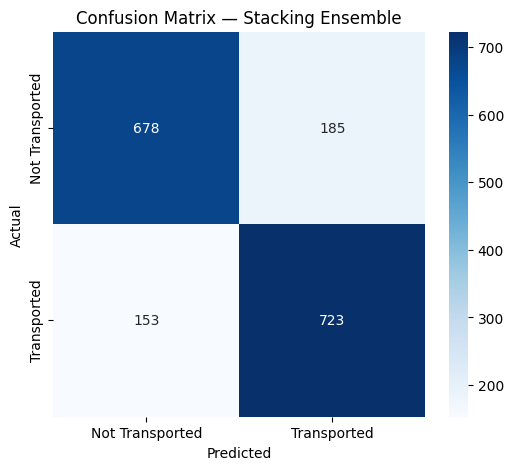

In [30]:
cm = confusion_matrix(y_test, stacking_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Transported", "Transported"],
    yticklabels=["Not Transported", "Transported"]
)

plt.title("Confusion Matrix — Stacking Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 18. Model Performance Comparison

The baseline model and ensemble models are compared using accuracy, precision, recall, and F1-score. This comparison helps identify whether ensemble learning provides an improvement over the simpler baseline.

In [31]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "BaggingClassifier",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Soft Voting",
        "Stacking"
    ],
    "Accuracy": [
        baseline_accuracy,
        rf_accuracy,
        bagging_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        cat_accuracy,
        voting_accuracy,
        stacking_accuracy
    ],
    "Precision": [
        baseline_precision,
        rf_precision,
        bagging_precision,
        xgb_precision,
        lgbm_precision,
        cat_precision,
        voting_precision,
        stacking_precision
    ],
    "Recall": [
        baseline_recall,
        rf_recall,
        bagging_recall,
        xgb_recall,
        lgbm_recall,
        cat_recall,
        voting_recall,
        stacking_recall
    ],
    "F1 Score": [
        baseline_f1,
        rf_f1,
        bagging_f1,
        xgb_f1,
        lgbm_f1,
        cat_f1,
        voting_f1,
        stacking_f1
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM,0.818861,0.820571,0.819635,0.820103
1,XGBoost,0.813111,0.812005,0.818493,0.815236
2,Soft Voting,0.813111,0.817031,0.810502,0.813754
3,Random Forest,0.807361,0.838548,0.764840,0.800000
4,Stacking,0.805635,0.796256,0.825342,0.810538
5,CatBoost,0.803335,0.794702,0.821918,0.808081
6,BaggingClassifier,0.801610,0.808362,0.794521,0.801382
7,Logistic Regression,0.787234,0.782998,0.799087,0.790960


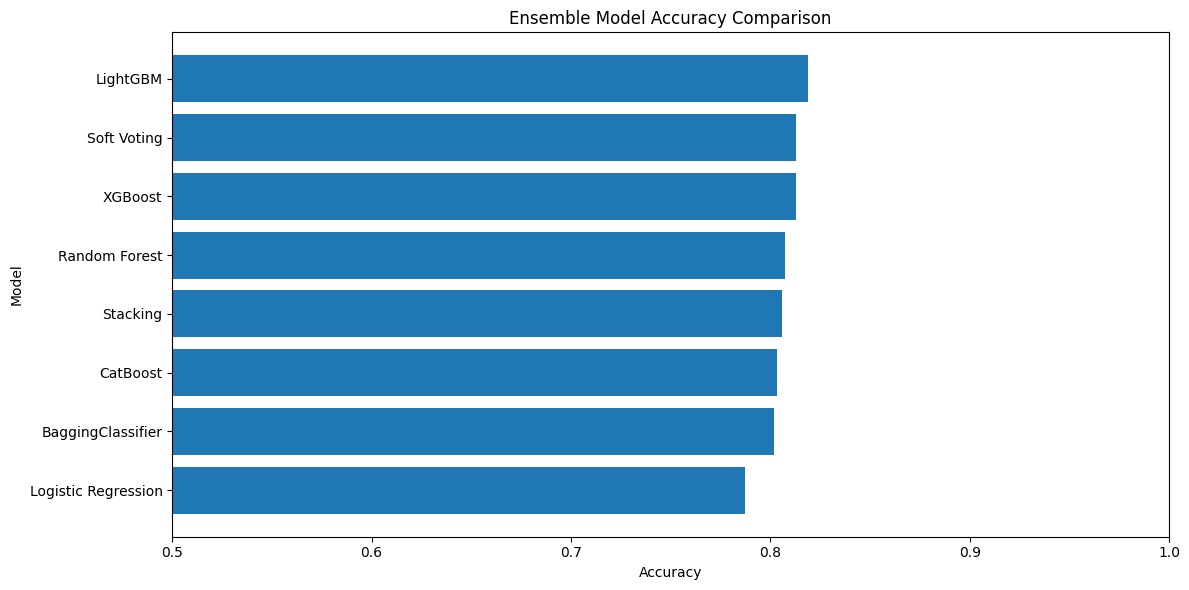

In [32]:
plt.figure(figsize=(12, 6))

results_sorted = results.sort_values(
    by="Accuracy",
    ascending=True
)

plt.barh(
    results_sorted["Model"],
    results_sorted["Accuracy"]
)

plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Ensemble Model Accuracy Comparison")
plt.xlim(0.5, 1.0)

plt.tight_layout()
plt.show()

## 19. Model Diversity Analysis

Ensemble methods benefit from combining models that make different errors. Prediction disagreement is therefore examined to understand the diversity among the base learners.

In [33]:
prediction_df = pd.DataFrame({
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred,
    "CatBoost": cat_pred
})

diversity_matrix = pd.DataFrame(
    index=prediction_df.columns,
    columns=prediction_df.columns,
    dtype=float
)

for model_a in prediction_df.columns:
    for model_b in prediction_df.columns:
        diversity_matrix.loc[model_a, model_b] = np.mean(
            prediction_df[model_a] != prediction_df[model_b]
        )

diversity_matrix

,Random Forest,XGBoost,LightGBM,CatBoost
Random Forest,0.000000,0.085106,0.083956,0.098332
XGBoost,0.085106,0.000000,0.032202,0.052329
LightGBM,0.083956,0.032202,0.000000,0.058079
CatBoost,0.098332,0.052329,0.058079,0.000000


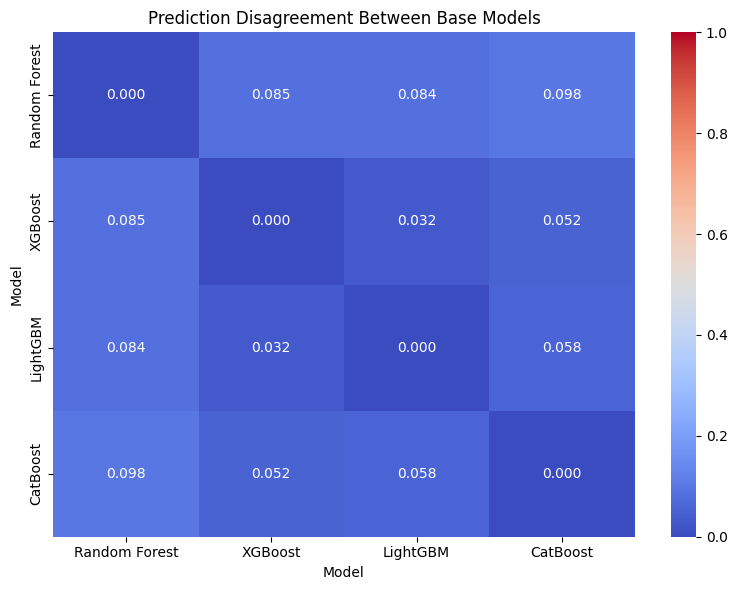

In [34]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    diversity_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

plt.title("Prediction Disagreement Between Base Models")
plt.xlabel("Model")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 20. Stacking Ensemble Evaluation

The stacking ensemble combines the predictions of Random Forest, XGBoost, and CatBoost using Logistic Regression as a meta-learner. Its performance is compared with the individual models and the voting ensemble.

In [35]:
print("Stacking Ensemble Results")
print("-" * 40)
print(f"Accuracy : {stacking_accuracy:.4f}")
print(f"Precision: {stacking_precision:.4f}")
print(f"Recall   : {stacking_recall:.4f}")
print(f"F1 Score : {stacking_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, stacking_pred))

Stacking Ensemble Results
----------------------------------------
Accuracy : 0.8056
Precision: 0.7963
Recall   : 0.8253
F1 Score : 0.8105

Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.79      0.80       863
        True       0.80      0.83      0.81       876

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739



## 21. Final Model Comparison

All implemented models are compared using accuracy, precision, recall, and F1-score. The comparison determines whether ensemble learning improves performance over the baseline model and identifies the strongest model for the dataset.

In [36]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "BaggingClassifier",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Soft Voting",
        "Stacking"
    ],
    "Accuracy": [
        baseline_accuracy,
        rf_accuracy,
        bagging_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        cat_accuracy,
        voting_accuracy,
        stacking_accuracy
    ],
    "Precision": [
        baseline_precision,
        rf_precision,
        bagging_precision,
        xgb_precision,
        lgbm_precision,
        cat_precision,
        voting_precision,
        stacking_precision
    ],
    "Recall": [
        baseline_recall,
        rf_recall,
        bagging_recall,
        xgb_recall,
        lgbm_recall,
        cat_recall,
        voting_recall,
        stacking_recall
    ],
    "F1 Score": [
        baseline_f1,
        rf_f1,
        bagging_f1,
        xgb_f1,
        lgbm_f1,
        cat_f1,
        voting_f1,
        stacking_f1
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM,0.818861,0.820571,0.819635,0.820103
1,XGBoost,0.813111,0.812005,0.818493,0.815236
2,Soft Voting,0.813111,0.817031,0.810502,0.813754
3,Random Forest,0.807361,0.838548,0.764840,0.800000
4,Stacking,0.805635,0.796256,0.825342,0.810538
5,CatBoost,0.803335,0.794702,0.821918,0.808081
6,BaggingClassifier,0.801610,0.808362,0.794521,0.801382
7,Logistic Regression,0.787234,0.782998,0.799087,0.790960


In [37]:
best_model_row = results.iloc[0]

print("Best Model")
print("-" * 30)
print("Model:", best_model_row["Model"])
print(f"Accuracy: {best_model_row['Accuracy']:.4f}")
print(f"Precision: {best_model_row['Precision']:.4f}")
print(f"Recall: {best_model_row['Recall']:.4f}")
print(f"F1 Score: {best_model_row['F1 Score']:.4f}")

Best Model
------------------------------
Model: LightGBM
Accuracy: 0.8189
Precision: 0.8206
Recall: 0.8196
F1 Score: 0.8201


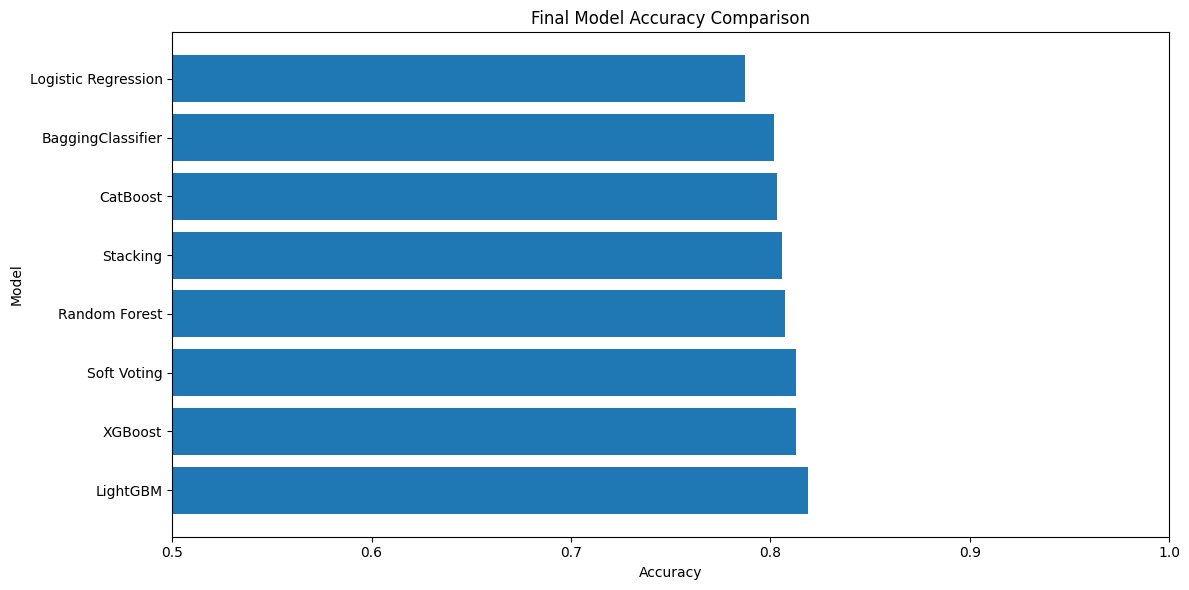

In [38]:
plt.figure(figsize=(12, 6))

plt.barh(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Final Model Accuracy Comparison")
plt.xlim(0.5, 1.0)

plt.tight_layout()
plt.show()

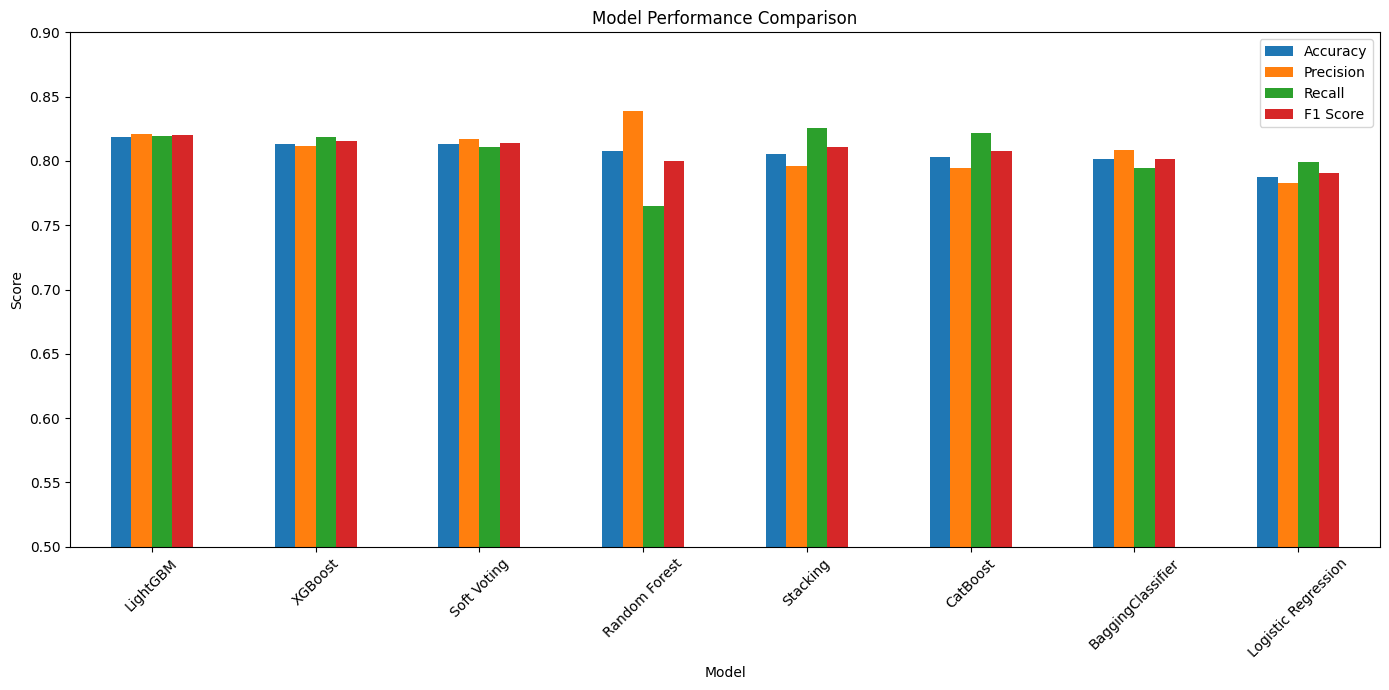

In [39]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.5, 0.9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 22. Business Interpretation

The ensemble experiments show that combining different machine learning models can improve predictive performance compared with a simple baseline.

The Soft Voting ensemble achieved 81.31% accuracy, improving over the Logistic Regression baseline at 78.72% and the individual CatBoost model at 80.33%.

The diversity analysis also showed that the base models make different predictions on a portion of the test samples. This disagreement provides useful diversity that can help an ensemble make more robust predictions.

The final model selection is based on the actual evaluation results rather than assuming that stacking or another ensemble method will always perform best.

## 23. Limitations

- The dataset contains missing values that require imputation.
- Model performance depends on the selected features and hyperparameters.
- Some boosting models produce similar predictions, resulting in limited diversity.
- The stacking ensemble is not guaranteed to outperform every individual model.
- Evaluation is based on a single held-out test split.
- Further hyperparameter tuning and cross-validation could potentially improve performance.

## 24. Conclusion

This task demonstrated the practical use of ensemble learning through Bagging, Boosting, Voting, and Stacking methods.

Random Forest and BaggingClassifier were used for bagging, while XGBoost, LightGBM, and CatBoost were used for boosting. A Soft Voting ensemble combined multiple strong classifiers, while Stacking used a Logistic Regression meta-learner.

The experiments demonstrated that ensemble performance depends on both individual model quality and model diversity. The final results provide a practical comparison of different ensemble strategies for the Spaceship Titanic prediction problem.